In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset, random_split

In [ ]:
df = pd.read_csv("C:\\Datasets\\IDS_Dataset\\Portscan-Friday-no-metadata.csv")

# Map labels to numeric
label_mapping = {'Benign': 0, 'PortScan': 1}
df['Label'] = df['Label'].map(label_mapping)

cols_to_drop = [
    "Fwd Packets Length Total", "Bwd Packets Length Total", "Fwd Packet Length Max", 
    "Bwd Packet Length Max", "Fwd Packet Length Min", "Bwd Packet Length Min",
    "Fwd Packet Length Std", "Bwd Packet Length Std", "Flow IAT Std", "Flow IAT Total",
    "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Std", 
    "Bwd IAT Max", "Bwd IAT Min", "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", 
    "Bwd URG Flags", "Packet Length Variance", "PSH Flag Count", "URG Flag Count", 
    "CWE Flag Count", "ECE Flag Count", "Down/Up Ratio", "Avg Packet Size",
    "Avg Fwd Segment Size", "Avg Bwd Segment Size", "Fwd Avg Bytes/Bulk", 
    "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", 
    "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate", "Subflow Bwd Bytes",
    "Init Fwd Win Bytes", "Init Bwd Win Bytes", "Fwd Act Data Packets", 
    "Fwd Seg Size Min", "Active Mean", "Active Std", "Active Max", "Active Min",
    "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
]
df = df.drop(columns=cols_to_drop, axis=1, errors='ignore')

# Clean Infinity and NaN values
df = df.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)

X = df.drop(columns=["Label"])
y = df["Label"]

# Initial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# 1. Apply SMOTE to training data (Strategy 0.2 means PortScan will be 20% of Benign)
sm = SMOTE(sampling_strategy=0.2, random_state=42)
X_res_np, y_res_np = sm.fit_resample(X_train, y_train)

# 2. Scaling - CRITICAL: Fit on train, transform both
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res_np)
X_test_scaled = scaler.transform(X_test)

# 3. Create Final Tensors
X_tensor = torch.tensor(X_res_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_res_np.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print(f"Data ready. Train shape: {X_tensor.shape}, Test shape: {X_test_tensor.shape}")

Data ready. Train shape: torch.Size([112844, 29]), Test shape: torch.Size([23905, 29])


In [ ]:
class PortScanDetector(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(PortScanDetector, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        return self.output(x)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        """
        Args:
            alpha (float): Weighting factor for the minority class. 
                           Values < 0.5 favor the majority, > 0.5 favor the minority.
            gamma (float): Focusing parameter. Higher values increase the 
                           focus on hard, misclassified examples.
            reduction (str): 'mean', 'sum', or 'none'.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard Cross Entropy Loss
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # Calculate probability of the correct class (pt)
        pt = torch.exp(-ce_loss)
        
        # Calculate Focal Loss: alpha * (1-pt)^gamma * CE
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [6]:
def create_client_loaders(X, y, num_clients=3, batch_size=32):
    dataset = TensorDataset(X, y)
    split_size = len(dataset) // num_clients
    lengths = [split_size] * (num_clients - 1)
    lengths.append(len(dataset) - sum(lengths))
    return [DataLoader(ds, batch_size=batch_size, shuffle=True) for ds in random_split(dataset, lengths)]

def federated_averaging(global_model, client_loaders, rounds=10, local_epochs=5):
    # Weight of 50.0 ensures the model cares deeply about the rare PortScan class
    weights = torch.tensor([1.0, 30.0]) 
    criterion = FocalLoss(alpha=0.25, gamma=2)

    for r in range(rounds):
        local_weights = []
        for i, loader in enumerate(client_loaders):
            local_model = copy.deepcopy(global_model)
            optimizer = torch.optim.Adam(local_model.parameters(), lr=0.0001) # Lower LR for stability
            
            local_model.train()
            for epoch in range(local_epochs):
                for batch_X, batch_y in loader:
                    optimizer.zero_grad()
                    loss = criterion(local_model(batch_X), batch_y)
                    loss.backward()
                    optimizer.step()
            local_weights.append(local_model.state_dict())
        
        # Aggregate weights at server
        global_dict = global_model.state_dict()
        for key in global_dict.keys():
            global_dict[key] = torch.stack([local_weights[j][key] for j in range(len(local_weights))], 0).mean(0)
        global_model.load_state_dict(global_dict)
        print(f"Round {r+1} complete.")
        
    return global_model

# Run Training
client_loaders = create_client_loaders(X_tensor, y_tensor, num_clients=3)
global_brain = federated_averaging(global_brain, client_loaders, rounds=10, local_epochs=5)

Round 1 complete.
Round 2 complete.
Round 3 complete.
Round 4 complete.
Round 5 complete.
Round 6 complete.
Round 7 complete.
Round 8 complete.
Round 9 complete.
Round 10 complete.


In [7]:
def evaluate_with_threshold(model, X_test_data, y_true_labels, threshold=0.5):
    model.eval() # Corrected: calling on model, not data
    with torch.no_grad():
        outputs = model(X_test_data)
        probs = torch.softmax(outputs, dim=1)[:, 1] 
        # Lower threshold (0.4) to catch more PortScans
        predictions = (probs > threshold).long()
        
    print(f"--- Global Performance (Threshold: {threshold}) ---")
    print(classification_report(y_true_labels, predictions, target_names=['Benign', 'PortScan'], zero_division=0))
    return predictions

# Execute Evaluation
preds = evaluate_with_threshold(global_brain, X_test_tensor, y_test_tensor, threshold=0.5)

--- Global Performance (Threshold: 0.5) ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     23529
    PortScan       0.92      0.98      0.95       376

    accuracy                           1.00     23905
   macro avg       0.96      0.99      0.98     23905
weighted avg       1.00      1.00      1.00     23905



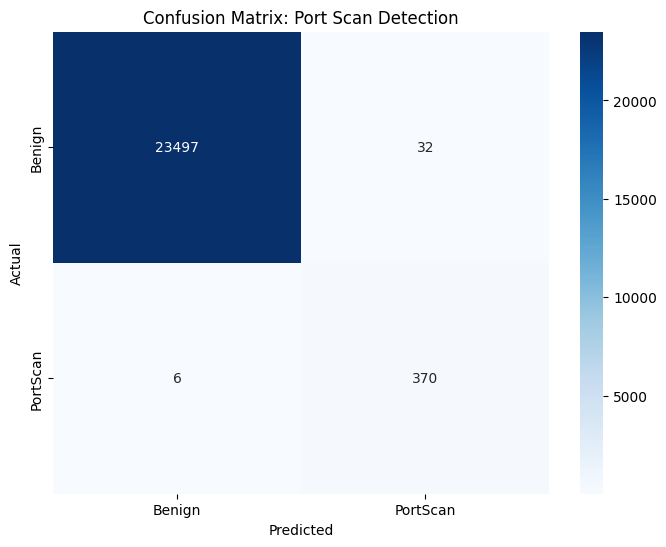

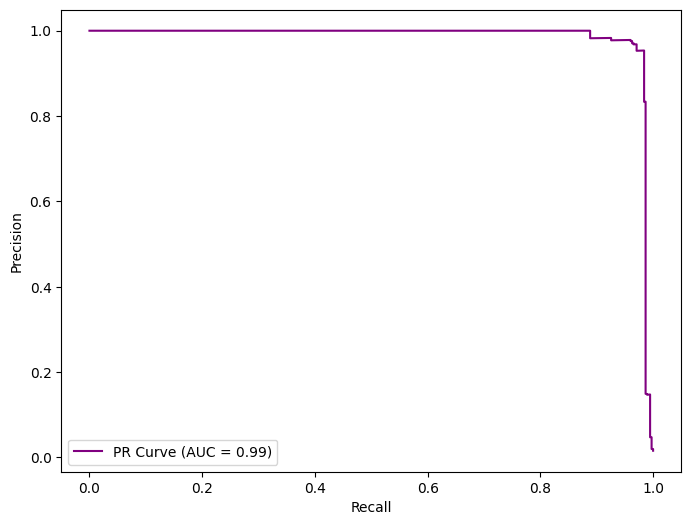

In [8]:
def plot_results(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'PortScan'], 
                yticklabels=['Benign', 'PortScan'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Port Scan Detection')
    plt.show()

plot_results(y_test_tensor.numpy(), preds.numpy())

# Precision-Recall Curve
global_brain.eval()
with torch.no_grad():
    probs = torch.softmax(global_brain(X_test_tensor), dim=1)[:, 1].numpy()

precision, recall, _ = precision_recall_curve(y_test_tensor.numpy(), probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='purple')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()